In [1]:
import pandas as pd
import numpy as np
index1 = pd.MultiIndex.from_arrays([['a', 'a', 'a', 'b', 'b', 'b', 'c', 'c', 'c', 'd', 'd', 'd'],
                [0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2]], names=['cloth', 'size'])

ser_obj = pd.Series(np.random.randn(12),index=index1)
df_obj=ser_obj.unstack(0)
print(df_obj)
#计算最小值有空值如何处理
df_obj.loc[0,'b']=np.nan
print(df_obj)
print('-'*50)
print(df_obj.min(axis=0))

cloth         a         b         c         d
size                                         
0      0.997022 -0.075223  1.019357  1.246637
1     -0.549103 -0.441960 -0.108146  0.372596
2     -1.363722  0.965427 -1.047686 -1.379488
cloth         a         b         c         d
size                                         
0      0.997022       NaN  1.019357  1.246637
1     -0.549103 -0.441960 -0.108146  0.372596
2     -1.363722  0.965427 -1.047686 -1.379488
--------------------------------------------------
cloth
a   -1.363722
b   -0.441960
c   -1.047686
d   -1.379488
dtype: float64


In [2]:
df_obj

cloth,a,b,c,d
size,,,,
0,0.997022,NaN,1.019357,1.246637
1,-0.549103,-0.441960,-0.108146,0.372596
2,-1.363722,0.965427,-1.047686,-1.379488


In [3]:
#观察数据分布的一种 非常常用方法
print(df_obj.describe())

cloth         a         b         c         d
count  3.000000  2.000000  3.000000  3.000000
mean  -0.305268  0.261734 -0.045492  0.079915
std    1.199112  0.995172  1.034945  1.337303
min   -1.363722 -0.441960 -1.047686 -1.379488
25%   -0.956412 -0.090113 -0.577916 -0.503446
50%   -0.549103  0.261734 -0.108146  0.372596
75%    0.223960  0.613580  0.455606  0.809616
max    0.997022  0.965427  1.019357  1.246637


In [4]:
df_obj.loc[:,'c']

size
0    1.019357
1   -0.108146
2   -1.047686
Name: c, dtype: float64

In [5]:
#计算最小值或者最大值的索引的位置
print(df_obj.loc[:,'c'].argmin())#argmin和argmax只能是series，不能是df

2


In [6]:
df_obj

cloth,a,b,c,d
size,,,,
0,0.997022,NaN,1.019357,1.246637
1,-0.549103,-0.441960,-0.108146,0.372596
2,-1.363722,0.965427,-1.047686,-1.379488


In [7]:
#返回的是一个series
#计算最小值或者最大值的索引值
df_obj.idxmin(axis=0, skipna=True)

cloth
a    2
b    1
c    2
d    2
dtype: int64

In [23]:
# import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = "IMDB-Movie-Data.csv"
df = pd.read_csv(file_path)
print(df.info())
print(df.head())
df.describe()
# os.getcwd()

,Rank,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,872.000000,936.000000
mean,500.500000,2012.783000,113.172000,6.723200,1.698083e+05,82.956376,58.985043
std,288.819436,3.205962,18.810908,0.945429,1.887626e+05,103.253540,17.194757
min,1.000000,2006.000000,66.000000,1.900000,6.100000e+01,0.000000,11.000000
25%,250.750000,2010.000000,100.000000,6.200000,3.630900e+04,13.270000,47.000000
50%,500.500000,2014.000000,111.000000,6.800000,1.107990e+05,47.985000,59.500000
75%,750.250000,2016.000000,123.000000,7.400000,2.399098e+05,113.715000,72.000000
max,1000.000000,2016.000000,191.000000,9.000000,1.791916e+06,936.630000,100.000000


### 任务：统计这1000部电影有多少导演和演员

In [9]:
# 获取平均评分
print(df["Rating"].mean())
print('-'*50)
# 导演的人数
print(len(set(df["Director"].tolist())))
print(len(df["Director"].unique())) #推荐这种方式
print(type(df))

6.723199999999999
--------------------------------------------------
644
644
<class 'pandas.DataFrame'>


In [10]:
# # 获取演员的人数 #二维列表
temp_actors_list = df["Actors"].str.split(", ").tolist()
print(temp_actors_list)


[['Chris Pratt', 'Vin Diesel', 'Bradley Cooper', 'Zoe Saldana'], ['Noomi Rapace', 'Logan Marshall-Green', 'Michael Fassbender', 'Charlize Theron'], ['James McAvoy', 'Anya Taylor-Joy', 'Haley Lu Richardson', 'Jessica Sula'], ['Matthew McConaughey,Reese Witherspoon', 'Seth MacFarlane', 'Scarlett Johansson'], ['Will Smith', 'Jared Leto', 'Margot Robbie', 'Viola Davis'], ['Matt Damon', 'Tian Jing', 'Willem Dafoe', 'Andy Lau'], ['Ryan Gosling', 'Emma Stone', 'Rosemarie DeWitt', 'J.K. Simmons'], ['Essie Davis', 'Andrea Riseborough', 'Julian Barratt,Kenneth Branagh'], ['Charlie Hunnam', 'Robert Pattinson', 'Sienna Miller', 'Tom Holland'], ['Jennifer Lawrence', 'Chris Pratt', 'Michael Sheen,Laurence Fishburne'], ['Eddie Redmayne', 'Katherine Waterston', 'Alison Sudol,Dan Fogler'], ['Taraji P. Henson', 'Octavia Spencer', 'Janelle Monáe,Kevin Costner'], ['Felicity Jones', 'Diego Luna', 'Alan Tudyk', 'Donnie Yen'], ["Auli'i Cravalho", 'Dwayne Johnson', 'Rachel House', 'Temuera Morrison'], ['Anne 

In [11]:
actors_list = [i for j in temp_actors_list for i in j]  #二维展为一维
actors_num = len(set(actors_list)) #set去重
print(actors_num) #演员的数量

2015


In [12]:
#想知道每个演员出演的电影数量
u,indices = np.unique(actors_list,return_counts = True)
print (u)
indices

['50 Cent' 'A.C. Peterson' 'AJ Michalka' ... 'Émilie Leclerc'
 'Ólafur Darri Ólafsson' 'Óscar Jaenada']


array([1, 1, 1, ..., 1, 1, 1], shape=(2015,))

### 8.3.1 电影时长的关系

66 191
125
--------------------------------------------------


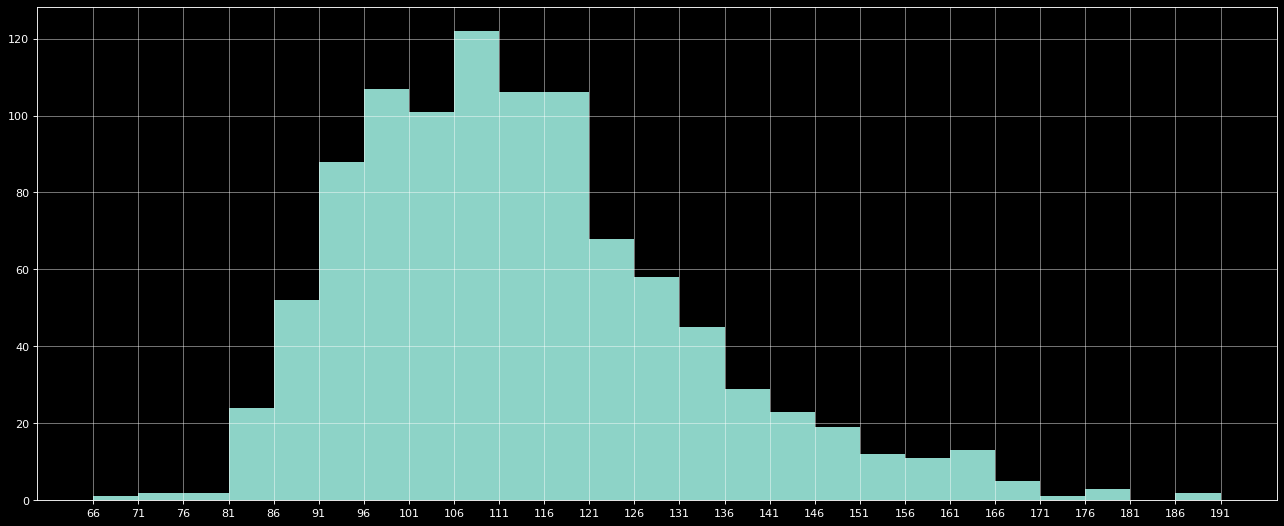

In [13]:
# rating,runtime分布情况
# 选择图形，直方图
# 准备数据
runtime_data = df["Runtime (Minutes)"].values

max_runtime = runtime_data.max()
min_runtime = runtime_data.min()
print(min_runtime,max_runtime)
# 计算组数
print(max_runtime - min_runtime)
print('-'*50)
num_bin = (max_runtime - min_runtime) // 5

# 设置图形的大小
plt.figure(figsize=(20, 8), dpi=80)
# 第二个bins参数必须为int或sequence或str，bins代表划分为多少个单元
plt.hist(runtime_data, int(num_bin))
plt.grid(alpha=0.5) #alpha是透明度
#range第三个参数是步长
plt.xticks(range(min_runtime, max_runtime + 5,5))

plt.show()

In [14]:
#电影评分的分布情况
# 获取平均评分
print(df["Rating"].mean())

# rating,runtime分布情况
# 选择图形，直方图
# 准备数据
runtime_data = df["Rating"].values
print(type(runtime_data))
max_runtime = runtime_data.max()
min_runtime = runtime_data.min()
print('-'*50)
print(max_runtime,min_runtime) #最大值最小值电影评分

6.723199999999999
<class 'numpy.ndarray'>
--------------------------------------------------
9.0 1.9


最大评分减去最小评分为7.1
组数为14.0


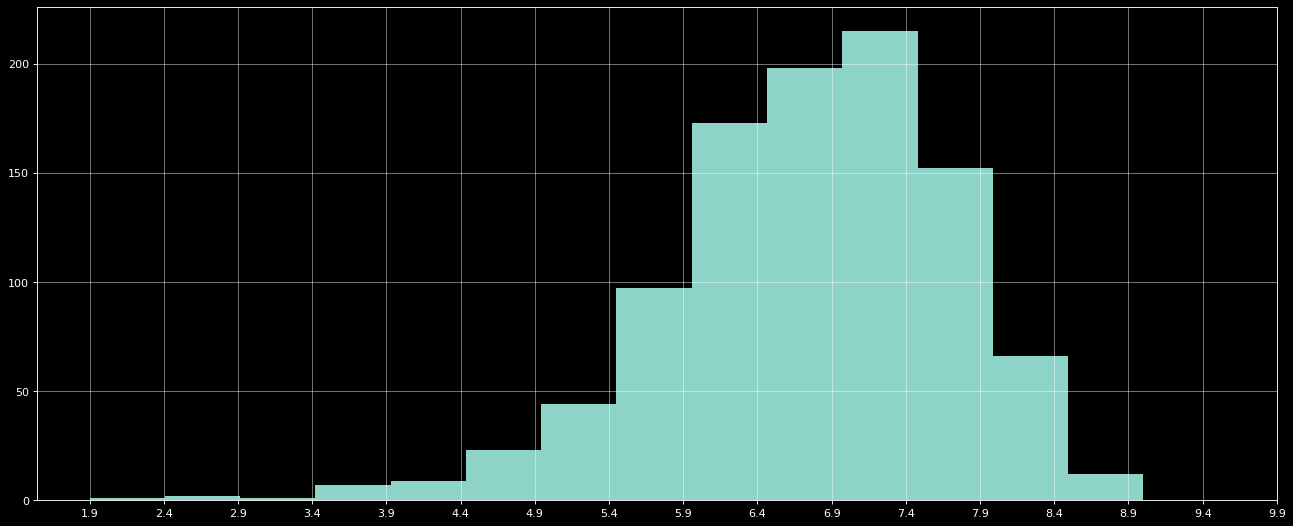

In [15]:
# 计算组数
print(f'最大评分减去最小评分为{max_runtime - min_runtime}')
num_bin = (max_runtime - min_runtime) // 0.5  #对不齐的原因是因为9.0-1.9不能整除0.5

print(f'组数为{num_bin}')
# 设置图形的大小
plt.figure(figsize=(20, 8), dpi=80)
# 第二个bins参数必须为int或sequence或str，bins代表划分为多少个单元
plt.hist(runtime_data, int(num_bin))
plt.grid(alpha=0.5)
#因为range的步长不支持0.5,自己做一个列表
_x = [min_runtime]
i = min_runtime
while i <= max_runtime + 0.5:
    i = i + 0.5
    _x.append(i)

plt.xticks(_x) #设置x轴的刻度

plt.show()

### 8.3.3 导演要拍什么题材电影

In [16]:


print(df["Genre"].head(3))  #看前几条数据，掌握格式，内容类型

0     Action,Adventure,Sci-Fi
1    Adventure,Mystery,Sci-Fi
2             Horror,Thriller
Name: Genre, dtype: str


In [17]:
# 统计分类的列表
temp_list = df["Genre"].str.split(",").tolist()  # [[],[],[]]
# 二维变为一维
genre_list = list(set([i for j in temp_list for i in j]))
print(len(genre_list)) # 20个题材类型
# 构造全为0的数组，行是原来的样本数，列是题材类型数目，one-hot编码，
zeros_df = pd.DataFrame(np.zeros((df.shape[0], len(genre_list))), columns=genre_list)
print(zeros_df)

20
     Sport  Animation  Comedy  Adventure  Action  Western  Sci-Fi  Musical  \
0      0.0        0.0     0.0        0.0     0.0      0.0     0.0      0.0   
1      0.0        0.0     0.0        0.0     0.0      0.0     0.0      0.0   
2      0.0        0.0     0.0        0.0     0.0      0.0     0.0      0.0   
3      0.0        0.0     0.0        0.0     0.0      0.0     0.0      0.0   
4      0.0        0.0     0.0        0.0     0.0      0.0     0.0      0.0   
..     ...        ...     ...        ...     ...      ...     ...      ...   
995    0.0        0.0     0.0        0.0     0.0      0.0     0.0      0.0   
996    0.0        0.0     0.0        0.0     0.0      0.0     0.0      0.0   
997    0.0        0.0     0.0        0.0     0.0      0.0     0.0      0.0   
998    0.0        0.0     0.0        0.0     0.0      0.0     0.0      0.0   
999    0.0        0.0     0.0        0.0     0.0      0.0     0.0      0.0   

     Fantasy  War  Romance  Thriller  Horror  Music  Biograp

In [18]:
# 给每个电影出现分类的位置赋值1,one-hot的中文是独热码
for i in range(df.shape[0]):
    # zeros_df.loc[0,["Sci-fi","Mucical"]] = 1
    #temp_list是二维列表，temp_list[i]是一个一维列表
    zeros_df.loc[i, temp_list[i]] = 1 #temp_list[i]是一个列表，里面是分类

zeros_df.head(3)

,Sport,Animation,Comedy,Adventure,Action,Western,Sci-Fi,Musical,Fantasy,War,Romance,Thriller,Horror,Music,Biography,Mystery,History,Drama,Crime,Family
0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
# 统计每个分类的电影的数量和，genre_count是什么类型？
genre_count = zeros_df.sum(axis=0)
print(genre_count)

Sport         18.0
Animation     49.0
Comedy       279.0
Adventure    259.0
Action       303.0
Western        7.0
Sci-Fi       120.0
Musical        5.0
Fantasy      101.0
War           13.0
Romance      141.0
Thriller     195.0
Horror       119.0
Music         16.0
Biography     81.0
Mystery      106.0
History       29.0
Drama        513.0
Crime        150.0
Family        51.0
dtype: float64


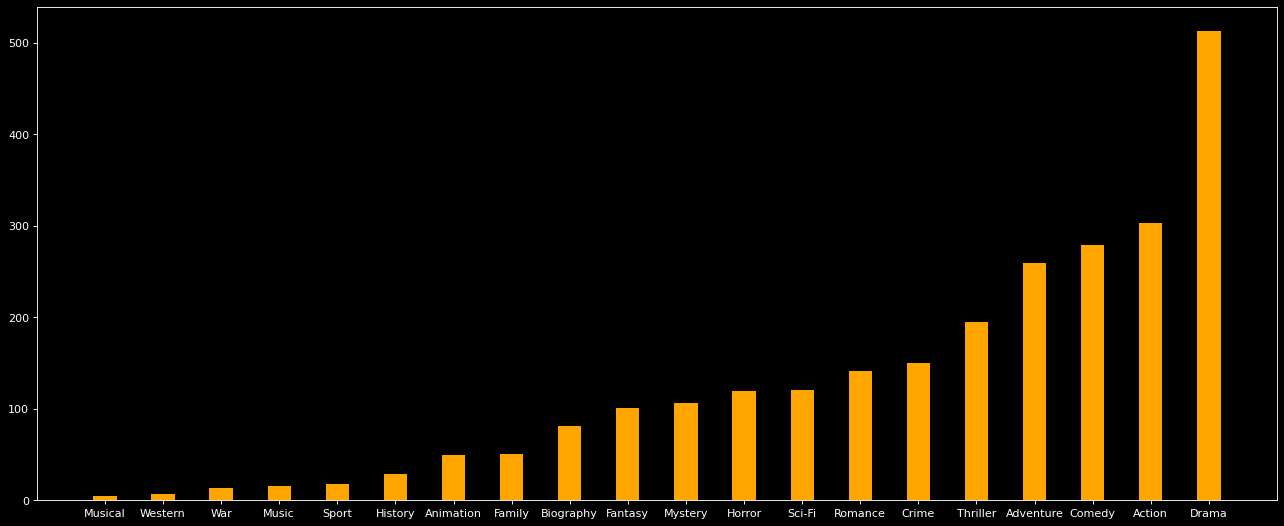

In [20]:
# 排序
genre_count = genre_count.sort_values()
_x = genre_count.index
_y = genre_count.values
# 画图
plt.figure(figsize=(20, 8), dpi=80)
plt.bar(range(len(_x)), _y, width=0.4, color="orange")
plt.xticks(range(len(_x)), _x)
plt.show()